In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Load data
df = pd.read_csv("data/synthetic_house_prices_20_years.csv")

df["Age"] = 2024 - df["Year Built"]
df["Bath per Bed"] = df["Bathrooms"] / (df["Bedrooms"] + 1)
df["Sqft per Room"] = df["Square Footage (House)"] / (df["Bedrooms"] + df["Bathrooms"] + 1)

# Target
y = df["Market Price"]

# Features
X = df.drop(columns=["Market Price"])

# Identify feature types
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

# Preprocessing
numeric_transformer = SimpleImputer(strategy="median")

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Linear Model

In [50]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

model.fit(X_train, y_train)

preds = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("R2:", r2_score(y_test, preds))

MAE: 725855.1291917443
R2: 0.4678944173602696


Ridge Regression

In [51]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", Ridge(alpha=10))
])

ridge_model.fit(X_train, y_train)
preds = ridge_model.predict(X_test)

print("R2:", r2_score(y_test, preds))

R2: 0.46942551037800684


Lasso

In [52]:
from sklearn.linear_model import Lasso

lasso_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", Lasso(alpha=0.01))
])

lasso_model.fit(X_train, y_train)
preds = lasso_model.predict(X_test)

print("R2:", r2_score(y_test, preds))

R2: 0.4674615003136603


c:\Program Files\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.717e+13, tolerance: 4.439e+11
  model = cd_fast.sparse_enet_coordinate_descent(


Polynomial

In [53]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

poly_model = Pipeline([
    ("preprocess", preprocessor),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", Ridge(alpha=1))
])

poly_model.fit(X_train, y_train)
preds = poly_model.predict(X_test)

print("R2:", r2_score(y_test, preds))

R2: 0.43498384446535


Random Forest

In [54]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

param_dist = {
    "model__n_estimators": [200, 400, 600, 800, 1000],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X, y)

print("Best R2:", random_search.best_score_)
print("Best parameters:")
print(random_search.best_params_)

best_model = random_search.best_estimator_

predictions = best_model.predict(X)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best R2: 0.47486959750442576
Best parameters:
{'model__n_estimators': 1000, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': 10}


In [55]:
import numpy as np
from sklearn.metrics import mean_squared_error

y_pred = best_model.predict(X_test)
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.7472549321751021
MAE: 494659.55622567295
RMSE: 623759.6971894271


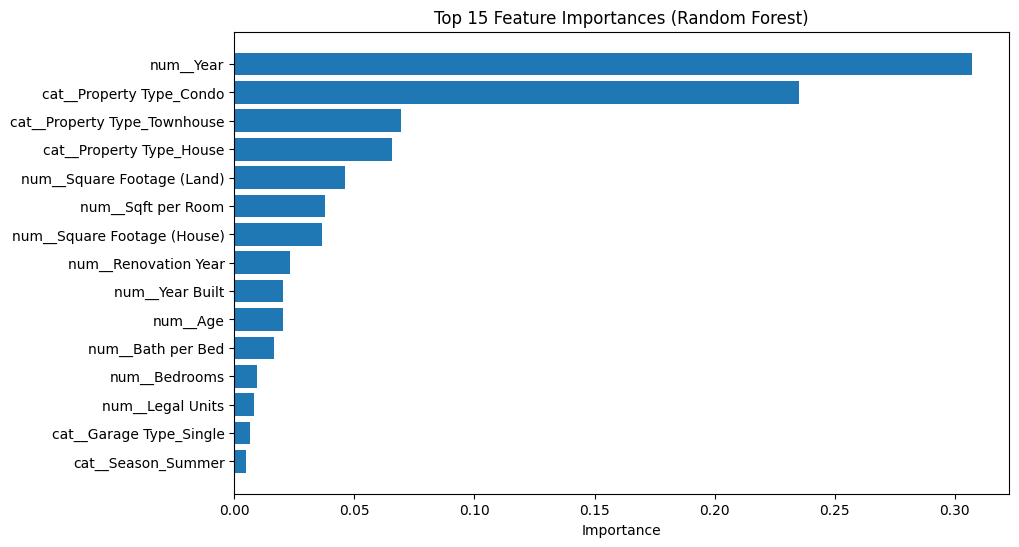

In [56]:
import matplotlib.pyplot as plt

# Extract the random forest model
rf = best_model.named_steps["model"]

# Get feature names after preprocessing
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()

# Feature importance
importances = rf.feature_importances_

# Create dataframe
feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_imp["Feature"][:15], feat_imp["Importance"][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()

Gradient Boosting

In [57]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

gb_preds = gb_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, gb_preds))
print("R2:", r2_score(y_test, gb_preds))

MAE: 722883.1967106701
R2: 0.45038072929801887


In [58]:
X_copy = X.copy()
X_copy.head()

,Neighborhood,Year,Season,Property Type,Bedrooms,Bathrooms,Year Built,Renovation Year,Garage Type,Square Footage (House),Square Footage (Land),Basement,Legal Units,Age,Bath per Bed,Sqft per Room
0,Kitsilano,2004,Spring,Triplex,1,3,1954,2000.0,Double,1308,6742,Not Finished,2,70,1.500000,261.600000
1,Kitsilano,2004,Summer,Condo,3,1,2022,NaN,Single,3947,2592,Finished,0,2,0.250000,789.400000
2,Kitsilano,2004,Fall,House,4,1,2006,NaN,NaN,919,9519,Not Finished,2,18,0.200000,153.166667
3,Kitsilano,2004,Winter,Condo,2,2,1960,NaN,Triple,2352,1555,Not Finished,2,64,0.666667,470.400000
4,Kitsilano,2005,Spring,Duplex,5,2,1960,1992.0,NaN,2474,7031,Not Finished,0,64,0.333333,309.250000


In [59]:
# Encode selected categorical features as non-negative integers for FA/NMF
cols_to_encode = ["Neighborhood", "Season", "Property Type", "Garage Type", "Basement"]

# Prefer X_copy if available, then X, then df
if "X_copy" in globals():
    encoded_df = X_copy.copy()
elif "X" in globals():
    encoded_df = X.copy()
else:
    encoded_df = df.copy()

encoding_maps = {}

for col in cols_to_encode:
    if col in encoded_df.columns:
        codes, uniques = pd.factorize(encoded_df[col].fillna("Missing"), sort=True)
        encoded_df[col] = codes.astype(int)
        encoding_maps[col] = dict(enumerate(uniques.tolist()))
    else:
        print(f"Column not found: {col}")

print("Encoded columns:", [c for c in cols_to_encode if c in encoded_df.columns])

# Optional: view code->category mappings
for col, mapping in encoding_maps.items():
    print(f"\n{col} mapping:")
    print(mapping)

encoded_df.head()

Encoded columns: ['Neighborhood', 'Season', 'Property Type', 'Garage Type', 'Basement']

Neighborhood mapping:
{0: 'Ambleside', 1: 'Brentwood', 2: 'Bridgeport', 3: 'British Properties', 4: 'Broadmoor', 5: 'Burke Mountain', 6: 'Burnaby Heights', 7: 'Cambie', 8: 'Caulfeild', 9: 'Central Lonsdale', 10: 'Central Port Coquitlam', 11: 'Cloverdale', 12: 'Coquitlam Centre', 13: 'Deer Lake', 14: 'Downtown', 15: 'Dundarave', 16: 'East Vancouver', 17: 'Edmonds', 18: 'Fleetwood', 19: 'Glenbrook North', 20: 'Glenwood', 21: 'Guildford', 22: 'Horseshoe Bay', 23: 'Kitsilano', 24: 'Ladner', 25: 'Lower Lonsdale', 26: 'Lynn Valley', 27: 'Maillardville', 28: 'Mary Hill', 29: 'Metrotown', 30: 'Mount Pleasant', 31: 'North Delta', 32: 'Queensborough', 33: 'Riverwood', 34: 'Seafair', 35: 'South Surrey', 36: 'Steveston', 37: 'Tsawwassen', 38: 'Upper Lonsdale', 39: 'Uptown', 40: 'West End', 41: 'Westwood Plateau', 42: 'Whalley'}

Season mapping:
{0: 'Fall', 1: 'Spring', 2: 'Summer', 3: 'Winter'}

Property Type 

,Neighborhood,Year,Season,Property Type,Bedrooms,Bathrooms,Year Built,Renovation Year,Garage Type,Square Footage (House),Square Footage (Land),Basement,Legal Units,Age,Bath per Bed,Sqft per Room
0,23,2004,1,4,1,3,1954,2000.0,0,1308,6742,1,2,70,1.500000,261.600000
1,23,2004,2,0,3,1,2022,NaN,2,3947,2592,0,0,2,0.250000,789.400000
2,23,2004,0,2,4,1,2006,NaN,1,919,9519,1,2,18,0.200000,153.166667
3,23,2004,3,0,2,2,1960,NaN,3,2352,1555,1,2,64,0.666667,470.400000
4,23,2005,1,1,5,2,1960,1992.0,1,2474,7031,1,0,64,0.333333,309.250000


In [60]:
from sklearn.decomposition import FactorAnalysis
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Build a numeric matrix from the encoded dataframe
fa_df = encoded_df.copy()
fa_X = fa_df.select_dtypes(include=[np.number])

if fa_X.shape[1] < 2:
    raise ValueError("Factor Analysis needs at least 2 numeric features.")

# Median-impute numeric missing values, then standardize
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()
X_imputed = imputer.fit_transform(fa_X)
X_scaled = scaler.fit_transform(X_imputed)

n_factors = min(5, fa_X.shape[1])
fa_model = FactorAnalysis(n_components=n_factors, random_state=42)
factor_scores = fa_model.fit_transform(X_scaled)

# Loadings matrix: rows=features, cols=factors
loadings = pd.DataFrame(
    fa_model.components_.T,
    index=fa_X.columns,
    columns=[f"Factor_{i+1}" for i in range(n_factors)]
)

# Approximate factor importance from variance of factor scores
factor_variance = factor_scores.var(axis=0)
factor_variance_ratio = factor_variance / factor_variance.sum()
factor_summary = pd.DataFrame(
    {
        "Factor": [f"Factor_{i+1}" for i in range(n_factors)],
        "Variance": factor_variance,
        "Variance_Ratio": factor_variance_ratio,
    }
)

print(f"Input shape for FA: {fa_X.shape}")
print(f"Number of factors used: {n_factors}")
print("\nTop absolute loadings per factor:")
for c in loadings.columns:
    print(f"\n{c}")
    print(loadings[c].abs().sort_values(ascending=False).head(5))

factor_summary

Input shape for FA: (3520, 16)
Number of factors used: 5

Top absolute loadings per factor:

Factor_1
Year Built         1.000000
Age                1.000000
Renovation Year    0.392351
Neighborhood       0.023887
Bathrooms          0.022902
Name: Factor_1, dtype: float64

Factor_2
Sqft per Room             0.796059
Bedrooms                  0.791753
Bath per Bed              0.628483
Square Footage (House)    0.568352
Bathrooms                 0.128867
Name: Factor_2, dtype: float64

Factor_3
Bath per Bed              0.711313
Square Footage (House)    0.646846
Bathrooms                 0.614700
Sqft per Room             0.570426
Bedrooms                  0.359277
Name: Factor_3, dtype: float64

Factor_4
Bathrooms                 0.708521
Bedrooms                  0.451856
Square Footage (House)    0.451421
Bath per Bed              0.240103
Year                      0.039772
Name: Factor_4, dtype: float64

Factor_5
Bathrooms                 0.111352
Property Type             0.060887

,Factor,Variance,Variance_Ratio
0,Factor_1,1.000000,0.242050
1,Factor_2,0.980120,0.237238
2,Factor_3,0.973774,0.235702
3,Factor_4,0.941550,0.227902
4,Factor_5,0.235942,0.057110


In [61]:
# Add factor scores to encoded_df for downstream analysis
factor_cols = [f"Factor_{i+1}" for i in range(factor_scores.shape[1])]
factor_scores_df = pd.DataFrame(factor_scores, columns=factor_cols, index=encoded_df.index)

# Avoid duplicate columns if this cell is rerun
encoded_df = encoded_df.drop(columns=[c for c in factor_cols if c in encoded_df.columns])
encoded_df = pd.concat([encoded_df, factor_scores_df], axis=1)

print("Added factor columns:", factor_cols)
encoded_df[factor_cols].head()

Added factor columns: ['Factor_1', 'Factor_2', 'Factor_3', 'Factor_4', 'Factor_5']


,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5
0,-1.508163,0.805777,2.497884,-0.068307,-0.781842
1,1.676103,0.268970,-1.387275,0.455942,-0.177060
2,0.926864,-1.469707,0.018100,1.096960,-0.311744
3,-1.227198,0.217421,0.448181,0.495652,0.106091
4,-1.227198,-1.124542,-0.315996,-0.662657,-0.080925


In [62]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Factor columns produced by FactorAnalysis
factor_predictors = [c for c in encoded_df.columns if c.startswith("Factor_")]
if not factor_predictors:
    raise ValueError("No factor columns found. Run the factor-score cell first.")

# Prefer existing target y; fallback to Sale Price column if needed
if "y" in globals():
    y_target = y.loc[encoded_df.index]
elif "Sale Price" in encoded_df.columns:
    y_target = encoded_df["Sale Price"]
else:
    raise ValueError("Target not found. Expected variable 'y' or column 'Sale Price'.")

# Build two feature sets:
# 1) factors only
# 2) original encoded features + factors
X_factors = encoded_df[factor_predictors].copy()
base_predictors = [c for c in encoded_df.columns if not c.startswith("Factor_")]
X_combined = encoded_df[base_predictors + factor_predictors].copy()

# Same split seed for fair comparison
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_factors, y_target, test_size=0.2, random_state=42
)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_combined, y_target, test_size=0.2, random_state=42
)

rf_params = dict(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)

rf_factors = RandomForestRegressor(**rf_params)
rf_combined = RandomForestRegressor(**rf_params)

rf_factors.fit(X_train_f, y_train_f)
rf_combined.fit(X_train_c, y_train_c)

pred_factors = rf_factors.predict(X_test_f)
pred_combined = rf_combined.predict(X_test_c)

results = pd.DataFrame(
    {
        "Model": ["Factors only", "Original + Factors"],
        "R2": [
            r2_score(y_test_f, pred_factors),
            r2_score(y_test_c, pred_combined),
        ],
        "MAE": [
            mean_absolute_error(y_test_f, pred_factors),
            mean_absolute_error(y_test_c, pred_combined),
        ],
        "RMSE": [
            mean_squared_error(y_test_f, pred_factors) ** 0.5,
            mean_squared_error(y_test_c, pred_combined) ** 0.5,
        ],
    }
)

print("Random Forest comparison")
print(f"Factor predictors: {factor_predictors}")
print(f"Base predictor count: {len(base_predictors)}")
print(results.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

combined_importance = pd.Series(
    rf_combined.feature_importances_, index=X_combined.columns
).sort_values(ascending=False)

combined_importance.head(15)

Random Forest comparison
Factor predictors: ['Factor_1', 'Factor_2', 'Factor_3', 'Factor_4', 'Factor_5']
Base predictor count: 16
             Model      R2          MAE         RMSE
      Factors only -0.0926 1018079.9470 1296879.1262
Original + Factors  0.4481  722514.5712  921715.0276


Property Type             0.294338
Year                      0.242026
Square Footage (Land)     0.051159
Factor_5                  0.043063
Factor_4                  0.042790
Neighborhood              0.042249
Factor_3                  0.034909
Factor_2                  0.034723
Square Footage (House)    0.031109
Renovation Year           0.030354
Sqft per Room             0.029036
Age                       0.021439
Season                    0.016407
Factor_1                  0.015603
Garage Type               0.015421
dtype: float64

In [63]:
from sklearn.decomposition import NMF
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

if "encoded_df" not in globals():
    raise ValueError("encoded_df not found. Run the encoding cell first.")

# Use encoded features and remove prior FA factors to avoid mixed latent spaces
nmf_source = encoded_df.drop(columns=[c for c in encoded_df.columns if c.startswith("Factor_")], errors="ignore")
X_nmf_raw = nmf_source.select_dtypes(include=["number"]).copy()

if X_nmf_raw.shape[1] < 2:
    raise ValueError("NMF needs at least 2 numeric features.")

# Align target
if "y" in globals():
    y_target_nmf = y.loc[X_nmf_raw.index]
elif "Sale Price" in encoded_df.columns:
    y_target_nmf = encoded_df.loc[X_nmf_raw.index, "Sale Price"]
else:
    raise ValueError("Target not found. Expected variable 'y' or column 'Sale Price'.")

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_nmf_raw, y_target_nmf, test_size=0.2, random_state=42
)

# Baseline model for direct comparison
baseline_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler(clip=True)),
    ("nmf", NMF(n_components=min(8, X_nmf_raw.shape[1]), init="nndsvda", random_state=42, max_iter=2000)),
    ("rf", RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)),
])

baseline_pipe.fit(X_train_n, y_train_n)
baseline_pred = baseline_pipe.predict(X_test_n)
baseline_r2 = r2_score(y_test_n, baseline_pred)

# Tuned model: search NMF and RF hyperparameters
tuned_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler(clip=True)),
    ("nmf", NMF(random_state=42, max_iter=2500)),
    ("rf", RandomForestRegressor(random_state=42, n_jobs=-1)),
])

param_dist = {
    "nmf__n_components": [4, 6, 8, 10, 12],
    "nmf__init": ["random", "nndsvd", "nndsvda", "nndsvdar"],
    "nmf__solver": ["cd", "mu"],
    "nmf__l1_ratio": [0.0, 0.2, 0.5, 0.8, 1.0],
    "nmf__alpha_W": [0.0, 1e-4, 1e-3, 1e-2, 1e-1],
    "nmf__alpha_H": [0.0, 1e-4, 1e-3, 1e-2, 1e-1],
    "rf__n_estimators": [200, 400, 600],
    "rf__max_depth": [None, 10, 20, 30],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": ["sqrt", "log2", None],
}

search = RandomizedSearchCV(
    tuned_pipe,
    param_distributions=param_dist,
    n_iter=35,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train_n, y_train_n)

best_nmf_rf = search.best_estimator_
tuned_pred = best_nmf_rf.predict(X_test_n)

tuned_results = {
    "R2": r2_score(y_test_n, tuned_pred),
    "MAE": mean_absolute_error(y_test_n, tuned_pred),
    "RMSE": mean_squared_error(y_test_n, tuned_pred) ** 0.5,
}

print("NMF + Random Forest tuning on encoded_df")
print(f"Input shape: {X_nmf_raw.shape}")
print(f"Baseline test R2: {baseline_r2:.4f}")
print(f"Best CV R2: {search.best_score_:.4f}")
print(f"Tuned test R2: {tuned_results['R2']:.4f}")
print(f"Test MAE: {tuned_results['MAE']:.4f}")
print(f"Test RMSE: {tuned_results['RMSE']:.4f}")
print("Best params:")
print(search.best_params_)

# Component importances from tuned model
nmf_step = best_nmf_rf.named_steps["nmf"]
rf_step = best_nmf_rf.named_steps["rf"]
component_cols = [f"NMF_{i+1}" for i in range(nmf_step.n_components_)]
nmf_importance = pd.Series(rf_step.feature_importances_, index=component_cols).sort_values(ascending=False)
nmf_importance

Fitting 5 folds for each of 35 candidates, totalling 175 fits


c:\Program Files\Python314\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [ 0.44244225  0.00147739  0.33279228  0.0673148   0.47316142  0.00225542
  0.24873203  0.03332468  0.02151872  0.4472678          nan  0.3577515
  0.00637779 -0.04412139 -0.13215091  0.45339366  0.34620995  0.33118764
  0.30762519  0.44409768  0.45227593  0.47770829 -0.04992327  0.02706168
  0.47903016  0.00753155 -0.00700267  0.00937341  0.47074832 -0.09354225
  0.02546043  0.06127057 -0.02208601  0.02178997 -0.17623723]
  warnings.warn(


NMF + Random Forest tuning on encoded_df
Input shape: (3520, 16)
Baseline test R2: 0.0696
Best CV R2: 0.4790
Tuned test R2: 0.4537
Test MAE: 719781.0414
Test RMSE: 917026.3807
Best params:
{'rf__n_estimators': 600, 'rf__min_samples_split': 10, 'rf__min_samples_leaf': 4, 'rf__max_features': None, 'rf__max_depth': 30, 'nmf__solver': 'cd', 'nmf__n_components': 12, 'nmf__l1_ratio': 0.2, 'nmf__init': 'nndsvda', 'nmf__alpha_W': 0.0001, 'nmf__alpha_H': 0.0}


NMF_9     0.392861
NMF_10    0.298777
NMF_8     0.035509
NMF_12    0.035429
NMF_11    0.035377
NMF_7     0.033679
NMF_2     0.029709
NMF_1     0.028668
NMF_4     0.028552
NMF_3     0.027544
NMF_5     0.026971
NMF_6     0.026924
dtype: float64

## Bagging Regressor

In [64]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

bagging_pipeline = Pipeline([
    ("preprocess", preprocessor),
    (
        "model",
        BaggingRegressor(
            estimator=DecisionTreeRegressor(random_state=42),
            random_state=42,
            n_jobs=-1,
        ),
    ),
])

#Parameters to test
bagging_param_dist = {
    "model__n_estimators": [50, 100, 200, 300],
    "model__max_samples": [0.5, 0.7, 0.9, 1.0],
    "model__max_features": [0.5, 0.7, 0.9, 1.0],
    "model__bootstrap": [True, False],
    "model__bootstrap_features": [False, True],
    "model__estimator__max_depth": [None, 5, 10, 20],
    "model__estimator__min_samples_split": [2, 5, 10],
    "model__estimator__min_samples_leaf": [1, 2, 4],
}

bagging_search = RandomizedSearchCV(
    bagging_pipeline,
    param_distributions=bagging_param_dist,
    n_iter=25,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

#Fit model
bagging_search.fit(X_train, y_train)
best_bagging = bagging_search.best_estimator_

bagging_pred = best_bagging.predict(X_test)

print("Bagging Regressor Results")
print(f"Best CV R2: {bagging_search.best_score_:.4f}")
print(f"Test R2: {r2_score(y_test, bagging_pred):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, bagging_pred):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, bagging_pred)):.4f}")
print("Best Params:") 
print(bagging_search.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Bagging Regressor Results
Best CV R2: 0.4956
Test R2: 0.4798
Test MAE: 701981.8967
Test RMSE: 894849.4584
Best Params:
{'model__n_estimators': 200, 'model__max_samples': 0.7, 'model__max_features': 0.9, 'model__estimator__min_samples_split': 10, 'model__estimator__min_samples_leaf': 4, 'model__estimator__max_depth': 5, 'model__bootstrap_features': False, 'model__bootstrap': False}
